<a href="https://colab.research.google.com/github/Radhameena15/zomato-data-analysis/blob/main/Zomato_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Exploratory data analysis**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [49]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [50]:
df = pd.read_csv('/content/drive/My Drive/zomato.csv', encoding='latin1')

In [51]:
df_country = pd.read_excel('/content/drive/My Drive/Country-Code.xlsx')

In [52]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [53]:
df_country.columns

Index(['Country Code', 'Country'], dtype='object')

In [54]:
final_df= pd.merge(df,df_country,on='Country Code', how='left')

In [55]:
final_df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Country
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Yes,No,No,No,3,4.8,Dark Green,Excellent,314,Phillipines
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Yes,No,No,No,3,4.5,Dark Green,Excellent,591,Phillipines
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Yes,No,No,No,4,4.4,Green,Very Good,270,Phillipines
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,No,No,No,No,4,4.9,Dark Green,Excellent,365,Phillipines
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Yes,No,No,No,4,4.8,Dark Green,Excellent,229,Phillipines


In [56]:
final_df.shape

(9551, 22)

In [57]:
final_df.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,9


In [58]:
final_df['Cuisines'].unique()

array(['French, Japanese, Desserts', 'Japanese',
       'Seafood, Asian, Filipino, Indian', ..., 'Burger, Izgara',
       'World Cuisine, Patisserie, Cafe', 'Italian, World Cuisine'],
      dtype=object)

In [59]:
final_df[(final_df['Cuisines'].isnull()) | (final_df['Cuisines'] == '')]

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Country
84,17284105,Cookie Shoppe,216,Albany,"115 N Jackson St, Albany, GA 31701",Albany,"Albany, Albany",-84.154000,31.577200,NaN,...,No,No,No,No,1,3.4,Orange,Average,34,United States
87,17284211,Pearly's Famous Country Cookng,216,Albany,"814 N Slappey Blvd, Albany, GA 31701",Albany,"Albany, Albany",-84.175900,31.588200,NaN,...,No,No,No,No,1,3.4,Orange,Average,36,United States
94,17284158,Jimmie's Hot Dogs,216,Albany,"204 S Jackson St, Albany, GA 31701",Albany,"Albany, Albany",-84.153400,31.575100,NaN,...,No,No,No,No,1,3.9,Yellow,Good,160,United States
297,17374552,Corkscrew Cafe,216,Gainesville,"51 W Main St, Dahlonega, GA 30533",Dahlonega,"Dahlonega, Gainesville",-83.985800,34.531800,NaN,...,No,No,No,No,3,3.9,Yellow,Good,209,United States
328,17501439,Dovetail,216,Macon,"543 Cherry St, Macon, GA 31201",Macon,"Macon, Macon",-83.627979,32.836410,NaN,...,No,No,No,No,3,3.8,Yellow,Good,102,United States
346,17606621,HI Lite Bar & Lounge,216,Miller,"109 N Broadway Ave, Miller, SD 57362",Miller,"Miller, Miller",-98.989100,44.515800,NaN,...,No,No,No,No,1,3.4,Orange,Average,11,United States
368,17059060,Hillstone,216,Orlando,"215 South Orlando Avenue, Winter Park, FL 32789",Winter Park,"Winter Park, Orlando",-81.365260,28.596682,NaN,...,No,No,No,No,3,4.4,Green,Very Good,1158,United States
418,17142698,Leonard's Bakery,216,Rest of Hawaii,"933 Kapahulu Ave, Honolulu, HI 96816",Kaimuki,"Kaimuki, Rest of Hawaii",-157.813432,21.284586,NaN,...,No,No,No,No,1,4.7,Dark Green,Excellent,707,United States
455,17616465,Tybee Island Social Club,216,Savannah,"1311 Butler Ave, Tybee Island, GA 31328",Tybee Island,"Tybee Island, Savannah",-80.848297,31.995810,NaN,...,No,No,No,No,1,3.9,Yellow,Good,309,United States


In [60]:
final_df['Cuisines'] = final_df['Cuisines'].fillna('Unknown')

In [61]:
final_df.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,0


# number of restaurants per country and  % of restaurants per country  -  Restaurant Count

In [62]:
final_df.Country.value_counts()

,count
Country,
India,8652
United States,434
United Kingdom,80
Brazil,60
South Africa,60
UAE,60
New Zealand,40
Turkey,34
Australia,24


In [63]:
country_names=final_df.Country.value_counts().index

In [64]:
final_df.Country.value_counts().values

array([8652,  434,   80,   60,   60,   60,   40,   34,   24,   22,   21,
         20,   20,   20,    4])

In [65]:
country_val=final_df.Country.value_counts().values

([<matplotlib.patches.Wedge at 0x7f968e84a1d0>,
 [Text(-1.082974277862112, 0.1927867046480056, 'India'),
  Text(1.0772816964394372, -0.22240536530526556, 'United States'),
  Text(1.0995865232164619, -0.030157552300104404, 'United Kingdom')],
 [Text(-0.5907132424702428, 0.10515638435345759, '94.39%'),
  Text(0.5876081980578747, -0.12131201743923574, '4.73%'),
  Text(0.5997744672089791, -0.01644957398187513, '0.87%')])

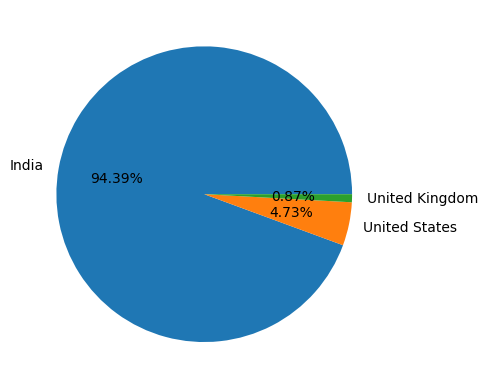

In [66]:
plt.pie(country_val[:3],labels=country_names[:3],autopct='%1.2f%%')

# **Average rating of restaurants per country/cuisine**  - Average Ratings

In [67]:
avg_rating_cuisines =final_df.groupby('Cuisines')['Aggregate rating'].mean().sort_values(ascending=False)

In [68]:
avg_rating_cuisines.head(10)

,Aggregate rating
Cuisines,
"Italian, Deli",4.9
"American, Coffee and Tea",4.9
"American, BBQ, Sandwich",4.9
"BBQ, Breakfast, Southern",4.9
"Italian, Bakery, Continental",4.9
"American, Burger, Grill",4.9
"Hawaiian, Seafood",4.9
"Mexican, American, Healthy Food",4.9
"American, Caribbean, Seafood",4.9


In [69]:
final_df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Country'],
      dtype='object')

# **Average cost for two people by country/city/cuisine**  -  Cost Analysis

In [70]:
avg_cost_country =final_df.groupby('Country')['Average Cost for two'].mean().sort_values(ascending=False)

In [71]:
avg_cost_country.head(10)

,Average Cost for two
Country,
Indonesia,281190.476190
Sri Lanka,2375.000000
Phillipines,1606.818182
India,623.370319
South Africa,419.733333
Qatar,223.750000
UAE,166.416667
Singapore,155.750000
Brazil,134.666667


In [72]:
avg_cost_city =final_df.groupby('City')['Average Cost for two'].mean().sort_values(ascending=False)

In [73]:
avg_cost_city.head(10)

,Average Cost for two
City,
Jakarta,308437.500000
Tangerang,250000.000000
Bogor,160000.000000
Bandung,150000.000000
Pasay City,3333.333333
Colombo,2375.000000
Mandaluyong City,2000.000000
Panchkula,2000.000000
Taguig City,1725.000000


In [74]:
avg_cost_cuisines =final_df.groupby('Cuisines')['Average Cost for two'].mean().sort_values(ascending=False)

In [75]:
avg_cost_cuisines.head(10)

,Average Cost for two
Cuisines,
"Asian, Indonesian, Western",800000.0
"French, Western",350000.0
"Cafe, Western",300000.0
Indonesian,300000.0
"Sushi, Japanese",250060.0
"Peranakan, Indonesian",250000.0
"Western, Asian, Cafe",250000.0
"Japanese, Sushi, Ramen",200000.0
"Desserts, Bakery, Western",200000.0




# **% of restaurants offering online delivery**  -  Online Delivery






In [76]:
final_df['Has Online delivery']=final_df['Has Online delivery'].apply(lambda x: 1 if x == 'Yes' else 0)

In [77]:
final_df['Has Online delivery'].sum()

np.int64(2451)

In [78]:
online_delivery_pct=(final_df['Has Online delivery'].sum()/final_df.shape[0])*100

In [79]:
(f"{online_delivery_pct:.2f}%")

'25.66%'

**Observations**
1. 25.66% of rastaurants have online delivery

# **How many restaurants have ratings > 4.5**  -  High Rating Distribution/Premium Restaurants

In [80]:
count_high_rating = (final_df['Aggregate rating'] > 4.5).sum()

In [81]:
count_high_rating

np.int64(206)

In [82]:
final_df.shape

(9551, 22)

**Observations**
1. Number of 206 rastaurants have excellent ratings out of 9551 Rastaurants

# **Top countries by average meal cost in local currency**  -  Currency Analysis

In [83]:
avg_meal_cost_local = final_df.groupby(['Country', 'Currency'])['Average Cost for two'].mean().sort_values(ascending=False).reset_index()

In [84]:
avg_meal_cost_local.head(10)

,Country,Currency,Average Cost for two
0,Indonesia,Indonesian Rupiah(IDR),281190.476190
1,Sri Lanka,Sri Lankan Rupee(LKR),2375.000000
2,Phillipines,Botswana Pula(P),1606.818182
3,India,Indian Rupees(Rs.),623.370319
4,South Africa,Rand(R),419.733333
5,Qatar,Qatari Rial(QR),223.750000
6,UAE,Emirati Diram(AED),166.416667
7,Singapore,Dollar($),155.750000
8,Brazil,Brazilian Real(R$),134.666667
9,Turkey,Turkish Lira(TL),84.852941


# **Most popular cuisines by number of restaurants**  - Popular Cuisines

In [85]:
# Remove missing cuisines
cuisine_df = final_df[final_df['Cuisines'].notnull()]

# Split the cuisines and explode the list into rows
cuisine_df = cuisine_df.assign(Cuisine=cuisine_df['Cuisines'].str.split(', ')).explode('Cuisine')


In [86]:
cuisine_counts = cuisine_df['Cuisine'].value_counts()

# Show top 10 cuisines
cuisine_counts.head(10)

,count
Cuisine,
North Indian,3960
Chinese,2735
Fast Food,1986
Mughlai,995
Italian,764
Bakery,745
Continental,736
Cafe,703
Desserts,653


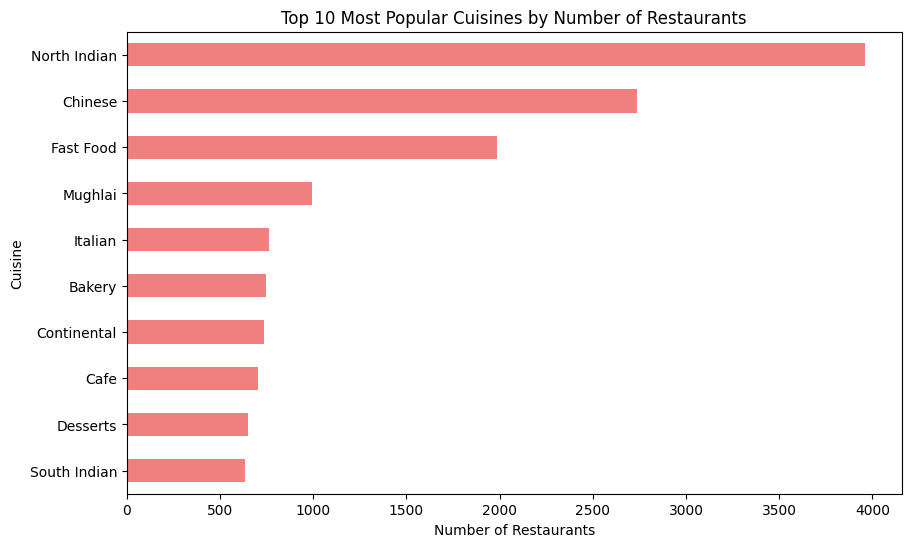

In [87]:
top_cuisines = cuisine_counts.head(10)

top_cuisines.plot(kind='barh', figsize=(10,6), color='lightcoral')
plt.title('Top 10 Most Popular Cuisines by Number of Restaurants')
plt.xlabel('Number of Restaurants')
plt.ylabel('Cuisine')
plt.gca().invert_yaxis()  # To keep highest at the top
plt.show()

# **Avg number of votes per restaurant (popularity indicator)**  - Votes Analysis

In [88]:
avg_votes_country = final_df.groupby('Country')['Votes'].mean().sort_values(ascending=False)

In [89]:
avg_votes_country.head(10)

,Votes
Country,
Indonesia,772.095238
UAE,493.516667
Turkey,431.470588
United States,428.221198
Phillipines,407.409091
South Africa,315.166667
New Zealand,243.025000
United Kingdom,205.487500
Qatar,163.800000


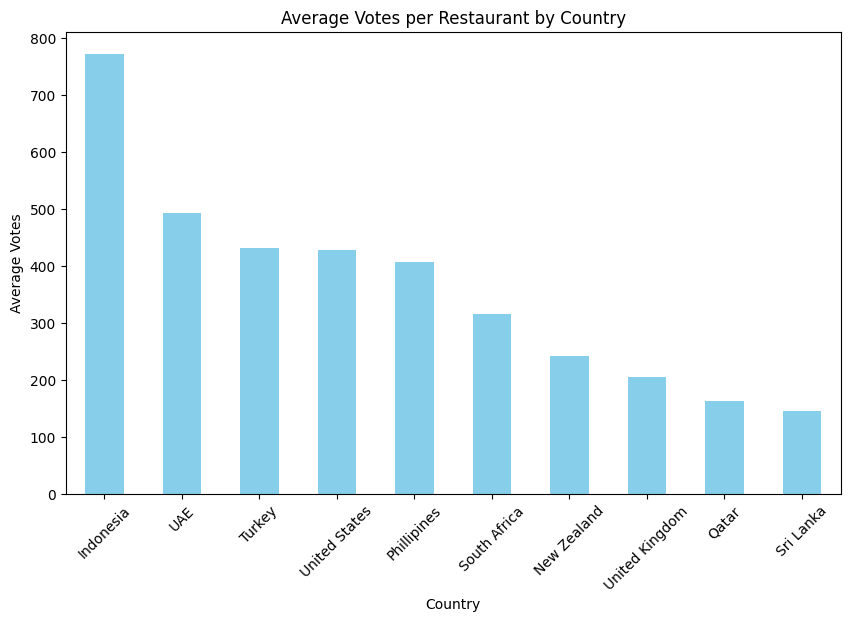

In [90]:
avg_votes_country.head(10).plot(kind='bar', figsize=(10,6), color='skyblue')
plt.title('Average Votes per Restaurant by Country')
plt.ylabel('Average Votes')
plt.xlabel('Country')
plt.xticks(rotation=45)
plt.show()

# **Is higher cost correlated with better ratings? (basic correlation)**  -  Rating vs Cost

In [91]:
# Remove rows with missing cost or rating, and rating = 0
df_corr = final_df[(final_df['Average Cost for two'].notnull()) & (final_df['Aggregate rating'] > 0)]


In [92]:
correlation = df_corr['Average Cost for two'].corr(df_corr['Aggregate rating'])


In [93]:
correlation

np.float64(0.07678988321518737)

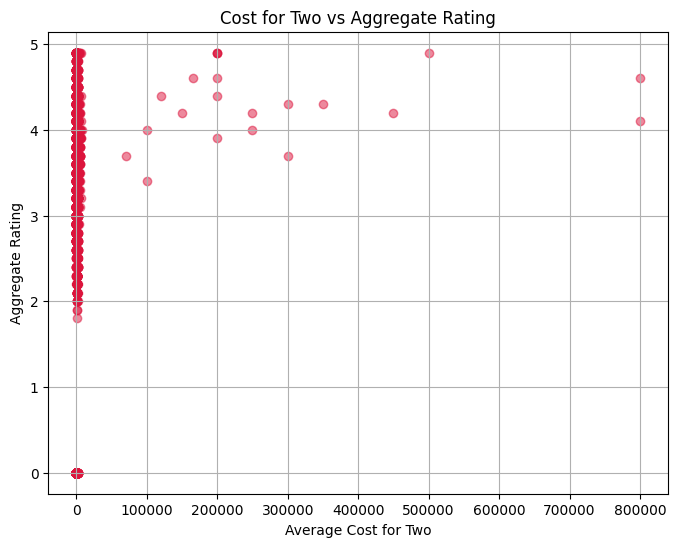

In [94]:
plt.figure(figsize=(8,6))
plt.scatter(final_df['Average Cost for two'], final_df['Aggregate rating'], alpha=0.5, color='crimson')
plt.title('Cost for Two vs Aggregate Rating')
plt.xlabel('Average Cost for Two')
plt.ylabel('Aggregate Rating')
plt.grid(True)
plt.show()

**Observation**
1. The correlation between the 'Average Cost for Two' and 'Aggregate Rating' was found to be 0.0768, indicating a very weak positive relationship